# Customer Segmentation — Model Experiment

This notebook evaluates clustering approaches on the cleaned customer dataset produced by `Eda.ipynb`. The deployment candidate is selected using quantitative metrics **and** business usability: sensible segment sizes, stable results, interpretable profiles, and the ability to assign a segment to a new customer.

**Models evaluated:** K-Means (primary), Gaussian Mixture Model (comparison), and DBSCAN (density/noise diagnostic).

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')

## 1. Load the cleaned data

The model experiment reads the version saved by the EDA notebook. Run the final save cell in `Eda.ipynb` first if this file is missing.

In [2]:
DATA_PATH = Path('../data/marketing_cleaned.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Cleaned data not found: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2052, 37)


,Education,Marital_Status,Income,Dt_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,...,Is_Parent,Total_Spending,Spend_Ratio,Total_Promo_Accepted,Any_Promo_Accepted,Total_Purchases,Days_as_Customer,Year_Joined,Age_Group,Income_Group
0,Graduation,Single,58138.0,2012-09-04,58,635,88,546,172,88,...,0,1617,0.0278,0,0,25,3406,2012,Senior (50-65),Mid (30-60k)
1,Graduation,Single,46344.0,2014-03-08,38,11,1,6,2,1,...,1,27,0.0006,0,0,6,2856,2014,Elderly (65+),Mid (30-60k)
2,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,...,0,776,0.0108,0,0,21,3055,2013,Senior (50-65),High (60-90k)
3,Graduation,Together,26646.0,2014-02-10,26,11,4,20,10,3,...,1,53,0.0020,0,0,8,2882,2014,Middle (35-50),Low (<30k)
4,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,...,1,422,0.0072,0,0,19,2904,2014,Middle (35-50),Mid (30-60k)


## 2. Define clustering features

We deliberately avoid IDs, labels from past campaigns, and highly redundant product-level columns. These seven features represent value, activity, recency, channel behaviour, engagement, and household purchasing context.

In [3]:
FEATURES = [
    'Income', 'Total_Spending', 'Total_Purchases', 'Recency',
    'NumWebVisitsMonth', 'Total_Promo_Accepted', 'Children'
]

missing_features = set(FEATURES) - set(df.columns)
if missing_features:
    raise ValueError(f'Missing expected features: {sorted(missing_features)}')

X = df[FEATURES].copy()
# Spend, income, and purchase counts are right-skewed; transform them before scaling.
LOG_FEATURES = ['Income', 'Total_Spending', 'Total_Purchases']
X[LOG_FEATURES] = np.log1p(X[LOG_FEATURES])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)

,Income,Total_Spending,Total_Purchases,Recency,NumWebVisitsMonth,Total_Promo_Accepted,Children
count,2052.00,2052.00,2052.00,2052.00,2052.00,2052.00,2052.00
mean,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-6.55,-2.60,-4.67,-1.69,-2.18,-0.44,-1.27
25%,-0.54,-0.93,-0.76,-0.86,-0.95,-0.44,-1.27
50%,0.18,0.25,0.26,0.00,0.28,-0.44,0.06
75%,0.75,0.90,0.83,0.86,0.69,-0.44,0.06
max,2.47,1.50,2.10,1.73,6.02,5.45,2.73


## 3. Compare K-Means candidates

Higher silhouette and Calinski–Harabasz scores are better. Lower Davies–Bouldin scores are better. These are guides, not the final decision: a segmentation also needs actionable, sufficiently large groups.

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster_pct
0,2,9374.338,0.314,1091.155,1.270,45.127
1,3,7922.772,0.246,832.920,1.486,22.953
2,4,6908.274,0.248,736.765,1.330,6.043
3,5,6269.177,0.211,660.777,1.544,6.043
4,6,5708.357,0.212,620.476,1.506,5.897
5,7,5319.289,0.216,579.540,1.467,5.897
6,8,5010.276,0.204,545.146,1.451,5.897


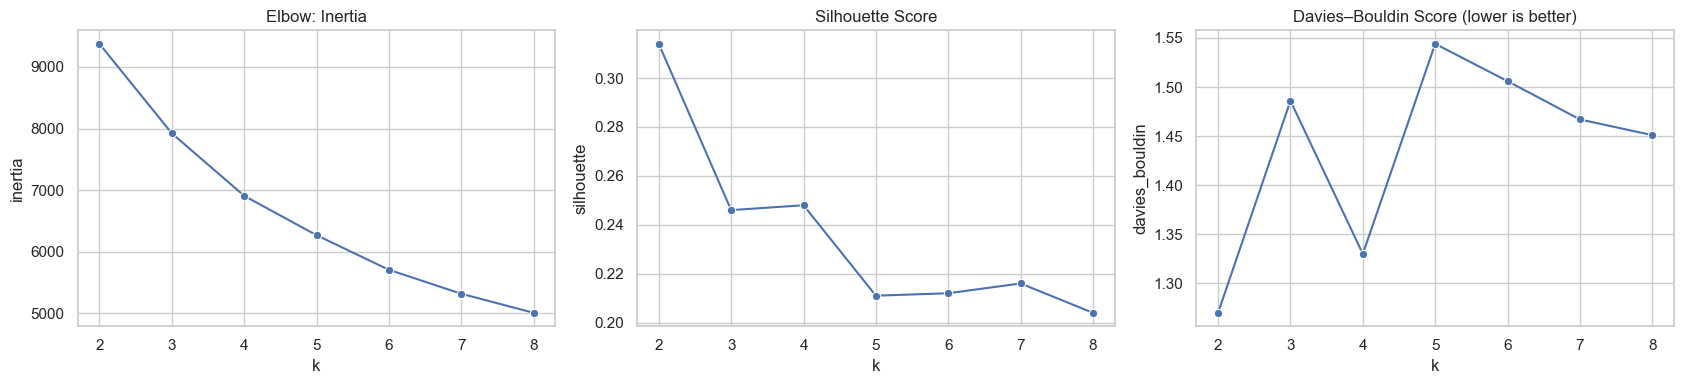

In [4]:
results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts()
    results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'smallest_cluster_pct': counts.min() / len(df) * 100
    })

kmeans_results = pd.DataFrame(results).round(3)
display(kmeans_results)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.lineplot(data=kmeans_results, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow: Inertia')
sns.lineplot(data=kmeans_results, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score')
sns.lineplot(data=kmeans_results, x='k', y='davies_bouldin', marker='o', ax=axes[2])
axes[2].set_title('Davies–Bouldin Score (lower is better)')
plt.tight_layout()

## 4. Alternative-model diagnostics

GMM is evaluated as a soft-clustering alternative. DBSCAN is useful for finding dense groups and unusual customers, but it has no native `predict` method for new customers; therefore it is not the initial API deployment model.

In [5]:
gmm_results = []
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=RANDOM_STATE)
    labels = gmm.fit_predict(X_scaled)
    gmm_results.append({
        'components': k,
        'BIC': gmm.bic(X_scaled),
        'AIC': gmm.aic(X_scaled),
        'silhouette': silhouette_score(X_scaled, labels)
    })

gmm_results = pd.DataFrame(gmm_results).round(3)
display(gmm_results)

dbscan_results = []
for eps in np.arange(0.6, 1.61, 0.2):
    labels = DBSCAN(eps=eps, min_samples=12).fit_predict(X_scaled)
    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise]))
    dbscan_results.append({
        'eps': round(float(eps), 2),
        'clusters': n_clusters,
        'noise_pct': round((~non_noise).mean() * 100, 1),
        'silhouette_non_noise': round(silhouette_score(X_scaled[non_noise], labels[non_noise]), 3) if n_clusters > 1 else np.nan
    })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results)

,components,BIC,AIC,silhouette
0,2,29524.319,29124.832,0.263
1,3,7330.257,6728.214,0.115
2,4,4644.863,3840.264,0.130
3,5,4375.388,3368.232,0.125
4,6,883.836,-325.876,0.143
5,7,-6022.234,-7434.503,0.071
6,8,-7373.282,-8988.108,0.069


,eps,clusters,noise_pct,silhouette_non_noise
0,0.6,7,66.3,0.171
1,0.8,8,29.8,0.056
2,1.0,9,16.9,0.042
3,1.2,8,10.6,0.040
4,1.4,5,6.1,0.086
5,1.6,1,1.9,NaN


## 5. Fit the selected deployment candidate

Choose `SELECTED_K` after inspecting the table above. Four segments are a good starting business hypothesis, but it should be changed if your diagnostics and profiles justify another value.

In [6]:
SELECTED_K = 4  # Document the final rationale in the README after reviewing metrics and profiles.
kmeans = KMeans(n_clusters=SELECTED_K, n_init=25, random_state=RANDOM_STATE)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# A deterministic business label is more useful than a raw cluster ID.
profile_for_names = df.groupby('Cluster')[['Total_Spending', 'Total_Purchases', 'Recency']].mean()
value_rank = profile_for_names['Total_Spending'].rank(method='first', ascending=False).astype(int)
segment_names = {
    cluster: f'Value Tier {rank}'
    for cluster, rank in value_rank.items()
}
df['Segment'] = df['Cluster'].map(segment_names)

segment_profile = (df.groupby(['Cluster', 'Segment'])
                   .agg(Customers=('Segment', 'size'),
                        Customer_Pct=('Segment', lambda s: len(s) / len(df) * 100),
                        Avg_Income=('Income', 'mean'),
                        Avg_Spending=('Total_Spending', 'mean'),
                        Avg_Purchases=('Total_Purchases', 'mean'),
                        Avg_Recency=('Recency', 'mean'),
                        Avg_Web_Visits=('NumWebVisitsMonth', 'mean'),
                        Promo_Acceptance=('Any_Promo_Accepted', 'mean'))
                   .round(2)
                   .sort_values('Avg_Spending', ascending=False))
segment_profile['Promo_Acceptance'] = (segment_profile['Promo_Acceptance'] * 100).round(1)
display(segment_profile)

,,Customers,Customer_Pct,Avg_Income,Avg_Spending,Avg_Purchases,Avg_Recency,Avg_Web_Visits,Promo_Acceptance
Cluster,Segment,,,,,,,,
3,Value Tier 1,124,6.04,79262.25,1530.86,21.15,48.10,3.70,100.0
2,Value Tier 2,488,23.78,72424.32,1158.59,19.68,47.24,2.51,24.0
1,Value Tier 3,655,31.92,54950.40,670.11,19.68,51.17,6.25,20.0
0,Value Tier 4,785,38.26,32656.28,64.95,6.90,48.43,6.55,8.0


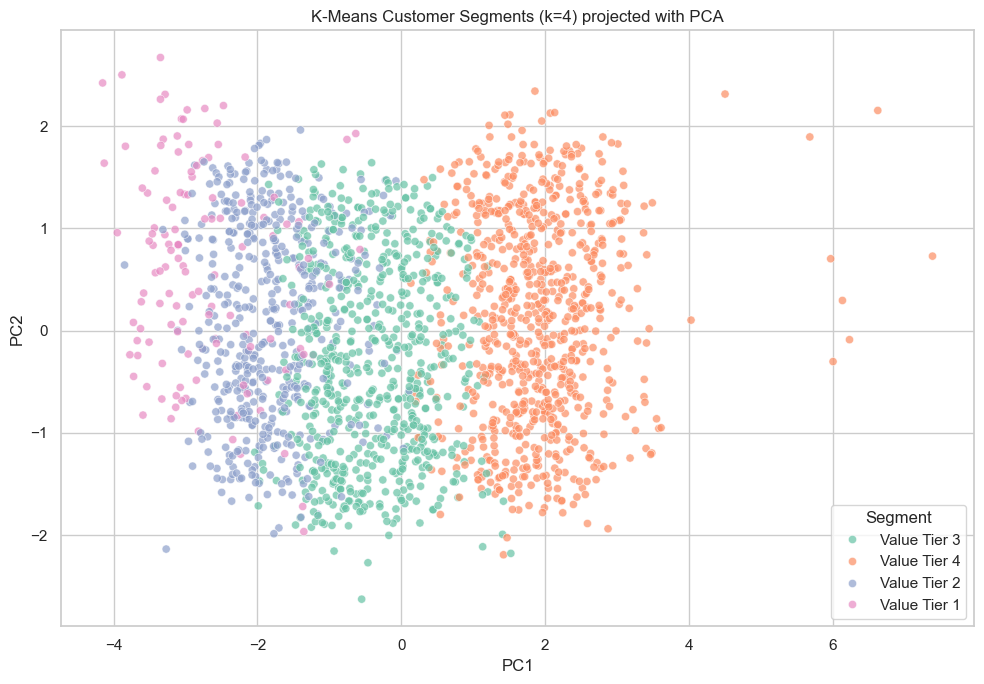

PCA variance explained: 60.7%
Final silhouette score: 0.248


In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordinates = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({'PC1': coordinates[:, 0], 'PC2': coordinates[:, 1], 'Segment': df['Segment']})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Segment', alpha=0.7, s=35, palette='Set2')
plt.title(f'K-Means Customer Segments (k={SELECTED_K}) projected with PCA')
plt.tight_layout()
plt.show()

print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')
print(f"Final silhouette score: {silhouette_score(X_scaled, df['Cluster']):.3f}")

## 6. Save experiment artifacts

These files are the handoff to the next phase: `data_transformation.py`, `model_trainer.py`, the train pipeline, FastAPI, and Streamlit. The production code must apply the same log transform, feature order, and fitted scaler.

In [8]:
ARTIFACT_DIR = Path('../artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(scaler, ARTIFACT_DIR / 'scaler.joblib')
joblib.dump(kmeans, ARTIFACT_DIR / 'kmeans_model.joblib')
segment_profile.to_csv(ARTIFACT_DIR / 'segment_profiles.csv')
df.to_csv(ARTIFACT_DIR / 'customers_with_segments.csv', index=False)

metadata = {
    'model_type': 'KMeans',
    'n_clusters': SELECTED_K,
    'features': FEATURES,
    'log_transformed_features': LOG_FEATURES,
    'random_state': RANDOM_STATE,
    'cluster_to_segment': {str(key): value for key, value in segment_names.items()}
}
(ARTIFACT_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2))

print(f'Artifacts saved to: {ARTIFACT_DIR.resolve()}')

Artifacts saved to: C:\Users\immad\OneDrive\Desktop\Customer Segmentation Project\artifacts
